### [Time Series Forecasting with LSTM in TensorFlow](https://pub.aimind.so/time-series-forecasting-with-lstm-in-tensorflow-df32aa5f579b)

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Tuple
from dataclasses import dataclass

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

np.set_printoptions(threshold=sys.maxsize, suppress=True, precision=6)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: "%.6f" % x)

%autosave 10

print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

if tf.test.gpu_device_name():
  print(f'Default GPU Device: {tf.test.gpu_device_name()}')

Autosaving every 10 seconds
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow version: 2.19.0
Keras version: 3.13.2
Numpy version: 2.0.2
Pandas version: 2.2.2
Num GPUs Available: 1
Default GPU Device: /device:GPU:0


In [2]:
def plot_series(time, series, format="-", start=0, end=None):
  """Helper function for plotting the graph of the temporal series"""
  plt.plot(time[start:end], series[start:end], format)
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(False)

def trend(time, slope=0.00):
  """Definition of a trend through slope and time"""
  return slope * time

def seasonal_pattern(season_time):
  """Arbitrary definition of a seasonal pattern """
  return np.where(season_time < 0.1,
                  np.cos(season_time * 6 * np.pi),
                  2 / np.exp(9 * season_time))

def seasonality(time, period, amplitude=1, phase=0):
  """Repeat a pattern at every period"""
  season_time = ((time + phase) % period) / period
  return amplitude * seasonal_pattern(season_time)

def noise(time, noise_level=1, seed=None):
  """Add white noise to the series"""
  rnd = np.random.RandomState(seed)
  return rnd.randn(len(time)) * noise_level

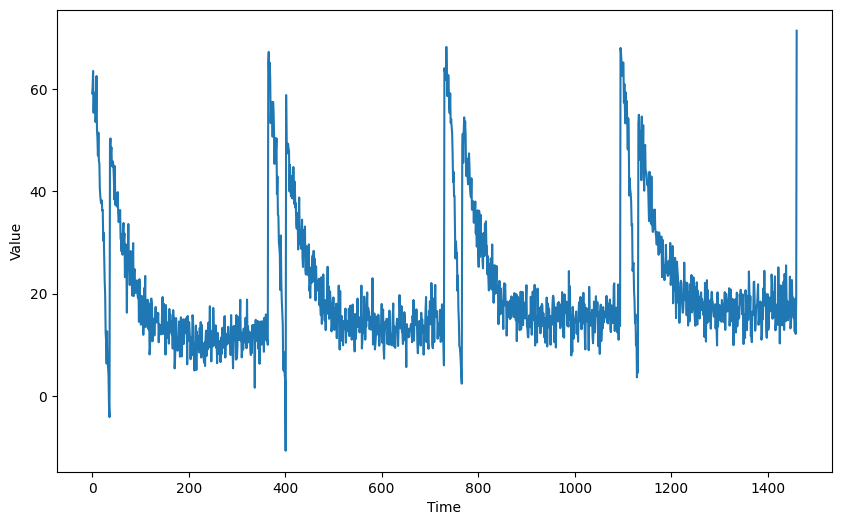

In [3]:
def generate_time_series():
  # The temporal dimension: 4 years of data
  time = np.arange(4 * 365 + 1, dtype="float32")

  # The initial series is just a right line that we will later modify with the other function s
  y_intercept = 10
  slope = 0.005
  series = trend(time, slope) + y_intercept

  # Adding seasonality
  amplitude = 50
  series += seasonality(time, period=365, amplitude=amplitude)

  # Adding noise
  noise_level = 3
  series += noise(time, noise_level, seed=51)

  return time, series


# Save the parameters of our temporale series
@dataclass
class G:
  TIME, SERIES = generate_time_series()
  SPLIT_TIME = 1100 # The training period will end on day 1100. The rest will be validation set
  WINDOW_SIZE = 20 # the number of days  we  will take into consideration for making our prediction
  BATCH_SIZE = 32 # how many items to provide per batch
  SHUFFLE_BUFFER_SIZE = 1000 # this parameter is needed to define the sampling buffer of Tensorflow


# plot the synthetic series
plt.figure(figsize=(10, 6))
plot_series(G.TIME, G.SERIES)
plt.show()

In [4]:
def train_val_split(time, series, time_step=G.SPLIT_TIME):
  """Divide the time series into training e validation sets"""
  time_train = time[:time_step]
  series_train = series[:time_step]
  time_valid = time[time_step:]
  series_valid = series[time_step:]

  return time_train, series_train, time_valid, series_valid

def windowed_dataset(series, window_size=G.WINDOW_SIZE, batch_size=G.BATCH_SIZE, shuffle_buffer=G.SHUFFLE_BUFFER_SIZE):
  """
  Create some temporal windows for creating  some features X and y.
  If, for example, we choose a window of 30, we will create a dataset formed by 30 points as X
  """
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
  dataset = dataset.shuffle(shuffle_buffer)
  dataset = dataset.map(lambda window: (window[:-1], window[-1]))
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset

In [5]:
series_train = G.SERIES[:G.SPLIT_TIME]

# create the dataset with temporal windows
dataset = windowed_dataset(series_train)

# divide into training and validation sets
time_train, series_train, time_valid, series_valid = train_val_split(G.TIME, G.SERIES)

In [6]:
def create_uncompiled_model():
  # definiamo un modello sequenziale
  model = tf.keras.models.Sequential([
      tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1),
                    input_shape=[None]),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(1024, return_sequences=True)),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(512, return_sequences=True)),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(256, return_sequences=True)),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
      tf.keras.layers.Dense(1),
  ])

  return model

In [7]:
def create_model():
  tf.random.set_seed(51)

  model = create_uncompiled_model()

  model.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["mae"])
  return model

model = create_model()

# train for 20 epochs and assign la callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=2, verbose=1)
history = model.fit(dataset, epochs=20, callbacks=[early_stopping])

display(model.summary())

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 9.1279 - mae: 9.6104
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.1392 - mae: 7.6128
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 7.1413 - mae: 7.6133
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.1415 - mae: 7.6119
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.1387 - mae: 7.6108
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.1397 - mae: 7.6116
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 7.1501 - mae: 7.6247
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 7.1415 - mae: 7.6130
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 7.1454 - mae: 7.6149
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 7.1470 - mae: 7.6238
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 7.1384 - mae: 7.6097
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 7.1381 - mae: 7.6099
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 2048)     │     8,404,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 1024)     │    10,489,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, None, 512)      │     2,623,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, None, 256)      │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,017,605 (255.65 MB)

 Trainable params: 22,339,201 (85.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,678,404 (170.43 MB)

None

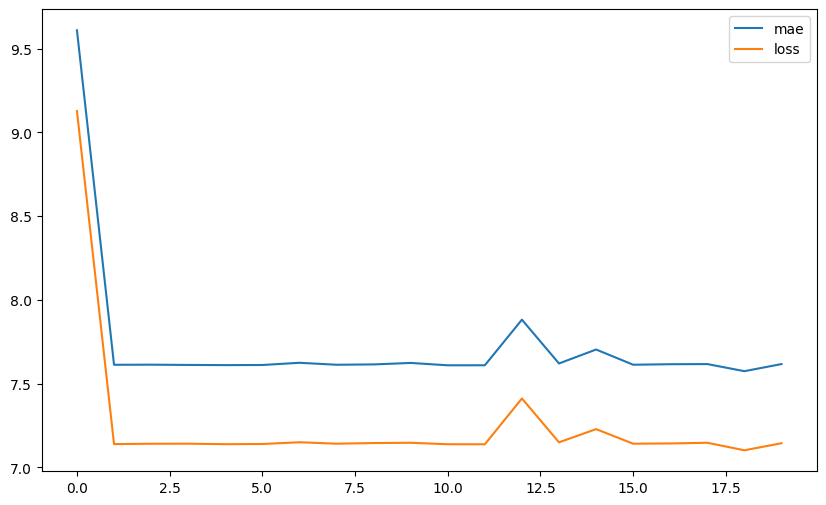

In [8]:
# plotting MAE and loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['loss'], label='loss')
plt.legend()
plt.show()

In [9]:
def compute_metrics(true_series, forecast):
  """Helper for printing MSE e MAE"""
  mse_metric = tf.keras.metrics.MeanSquaredError()
  mse_metric.update_state(true_series, forecast)
  mse = mse_metric.result().numpy()

  # Calculate MAE
  mae_metric = tf.keras.metrics.MeanAbsoluteError()
  mae_metric.update_state(true_series, forecast)
  mae = mae_metric.result().numpy()

  return mse, mae

def model_forecast(model, series, window_size):
  """Function to convert the input series into a Dataset with time windows for the prediction"""
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda w: w.batch(window_size))
  ds = ds.batch(32).prefetch(1)
  forecast = model.predict(ds)
  return forecast

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


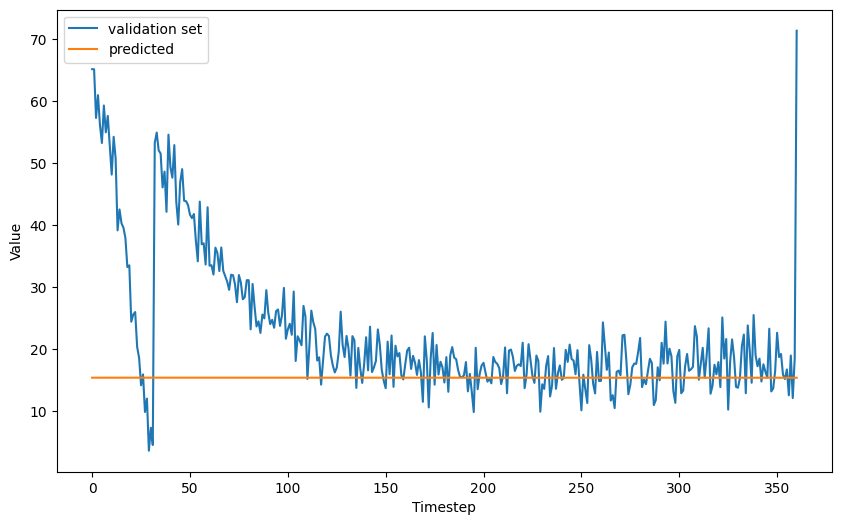

In [10]:
# Prediction on the whole time series
all_forecast = model_forecast(model, G.SERIES, G.WINDOW_SIZE).squeeze()

# Part for validation
val_forecast = all_forecast[G.SPLIT_TIME - G.WINDOW_SIZE:-1]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(series_valid, label="validation set")
plt.plot(val_forecast, label="predicted")
plt.xlabel("Timestep")
plt.ylabel("Value")
plt.legend()
plt.show()

In [11]:
mse, mae = compute_metrics(series_valid, val_forecast)
print(f"mse: {mse:.2f}, mae: {mae:.2f}")

mse: 186.53, mae: 8.42


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


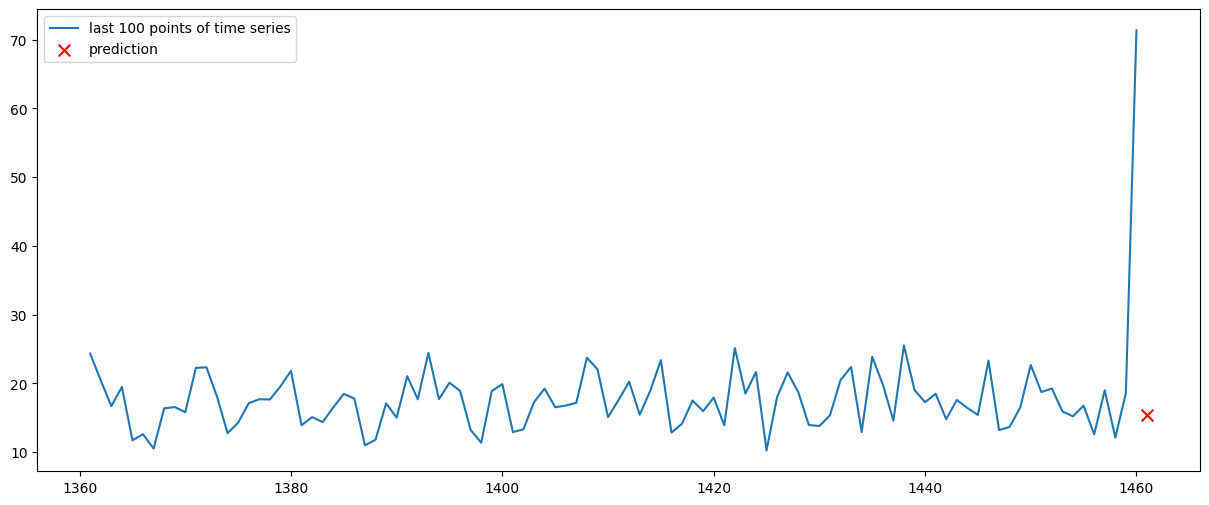

In [12]:
new_forecast = []

new_forecast_series = G.SERIES[-G.WINDOW_SIZE:]

pred = model.predict(new_forecast_series[np.newaxis])

plt.figure(figsize=(15, 6))
plt.plot(G.TIME[-100:], G.SERIES[-100:], label="last 100 points of time series")
plt.scatter(max(G.TIME)+1, pred, color="red", marker="x", s=70, label="prediction")
plt.legend()
plt.show()